In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

SAVE   = '/tmp/agro_eda/'
OUTPUT = '/Volumes/weather/weather15/up15/'

import os
os.makedirs(SAVE, exist_ok=True)

df = pd.read_csv(
    '/Volumes/weather/weather15/up15/agro_up_clean.csv',
    low_memory=False
)
df['date']  = pd.to_datetime(df['date'], errors='coerce')
df['year']  = df['date'].dt.year
df['month'] = df['date'].dt.month

print("=" * 60)
print("AG4P-8 | STEP 1 - Base Dataset Loaded")
print("=" * 60)
print("  Shape  :", df.shape)
print("  Cities :", df['city_clean'].nunique())
print("  Years  :", sorted(df['year'].unique().tolist()))

# Drop 2024 — incomplete year, only 50 days
df = df[df['year'] < 2024].copy()
print()
print("  After dropping incomplete 2024:")
print("  Shape  :", df.shape)
print("  Years  :", sorted(df['year'].unique().tolist()))

AG4P-8 | STEP 1 - Base Dataset Loaded
  Shape  : (258200, 28)
  Cities : 50
  Years  : [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024]

  After dropping incomplete 2024:
  Shape  : (255650, 28)
  Years  : [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]


In [0]:
print("=" * 60)
print("AG4P-8 | STEP 2 - Adding Base Engineered Columns")
print("=" * 60)

import math

# Cyclical month encoding — so Dec and Jan are close together
df['month_sin'] = df['month'].apply(
    lambda x: round(math.sin(2 * math.pi * x / 12), 4)
)
df['month_cos'] = df['month'].apply(
    lambda x: round(math.cos(2 * math.pi * x / 12), 4)
)

# Day of year — for onset detection
df['day_of_year'] = df['date'].dt.dayofyear

# Season label
df['season'] = df['month'].map({
    12:'Winter',  1:'Winter',   2:'Winter',
    3:'Zaid',     4:'Zaid',     5:'Zaid',
    6:'Kharif',   7:'Kharif',   8:'Kharif', 9:'Kharif',
    10:'Rabi',    11:'Rabi'
})

# Monsoon flag
df['is_monsoon'] = df['month'].isin([6,7,8,9]).astype(int)

# Pre-monsoon flag — PS1 feature window
df['is_pre_monsoon'] = df['month'].isin([3,4,5]).astype(int)

# Rain binary — already exists as rain_occurred, verify
if 'rain_occurred' not in df.columns:
    df['rain_occurred'] = (df['precip_total'] > 0).astype(int)

# Temperature range per day
df['temp_range'] = (df['temp_max'] - df['temp_min']).round(3)

# Region split (West/East UP at median longitude)
mid_lng = df['longitude'].median()
df['region'] = df['longitude'].apply(
    lambda x: 'West_UP' if x < mid_lng else 'East_UP'
)

print("  New columns added:")
new_cols = ['month_sin','month_cos','day_of_year',
            'season','is_monsoon','is_pre_monsoon',
            'temp_range','region']
for col in new_cols:
    print("   +", col, "| sample:", df[col].iloc[0])

print()
print("  Updated shape:", df.shape)

AG4P-8 | STEP 2 - Adding Base Engineered Columns
  New columns added:
   + month_sin | sample: 0.5
   + month_cos | sample: 0.866
   + day_of_year | sample: 1
   + season | sample: Winter
   + is_monsoon | sample: 0
   + is_pre_monsoon | sample: 0
   + temp_range | sample: 14.0
   + region | sample: West_UP

  Updated shape: (255650, 36)


In [0]:
print("=" * 60)
print("AG4P-8 | STEP 3 - Final Column Selection")
print("=" * 60)

# Define final column decisions
col_decisions = [
    # column              PS1      PS2      PS3      action
    ('date',              'KEY',   'KEY',   'KEY',   'keep'),
    ('city_clean',        'KEY',   'KEY',   'KEY',   'keep'),
    ('latitude',          'feat',  'feat',  'feat',  'keep'),
    ('longitude',         'feat',  'feat',  'feat',  'keep'),
    ('year',              'feat',  '-',     '-',     'keep'),
    ('month',             'feat',  '-',     'feat',  'keep'),
    ('month_sin',         'feat',  '-',     'feat',  'keep'),
    ('month_cos',         'feat',  '-',     'feat',  'keep'),
    ('day_of_year',       'feat',  '-',     '-',     'keep'),
    ('season',            'feat',  'feat',  '-',     'keep'),
    ('is_monsoon',        'feat',  '-',     '-',     'keep'),
    ('is_pre_monsoon',    'feat',  '-',     '-',     'keep'),
    ('region',            'feat',  'feat',  'feat',  'keep'),
    ('temp_mean',         'TARGET','feat',  'feat',  'keep'),
    ('temp_max',          'feat',  'feat',  '-',     'keep'),
    ('temp_min',          'feat',  'feat',  '-',     'keep'),
    ('temp_range',        'feat',  'feat',  '-',     'keep'),
    ('humidity_mean',     'feat',  'feat',  '-',     'keep'),
    ('dew_mean',          'feat',  'feat',  '-',     'keep'),
    ('precip_total',      'feat',  'feat',  '-',     'keep'),
    ('rain_occurred',     'feat',  'feat',  '-',     'keep'),
    ('cloud_mean',        'feat',  'feat',  'feat',  'keep'),
    ('cloud_low_mean',    'feat',  '-',     'feat',  'keep'),
    ('cloud_mid_mean',    '-',     '-',     '-',     'drop -- corr with cloud_mean'),
    ('cloud_high_mean',   '-',     '-',     '-',     'drop -- corr with cloud_mean'),
    ('wind_mean_100m',    'feat',  'feat',  'TARGET','keep'),
    ('wind_max_100m',     'feat',  '-',     'feat',  'keep'),
    ('wind_std_100m',     'feat',  '-',     'feat',  'keep'),
    ('wind_gusts_max',    'feat',  '-',     'feat',  'keep'),
    ('wind_mean_10m',     '-',     '-',     '-',     'drop -- 0.97 corr with 100m'),
    ('wind_max_10m',      '-',     '-',     '-',     'drop -- 0.89 corr with 100m'),
    ('pressure_mean',     'feat',  'feat',  '-',     'keep'),
    ('surface_pressure_mean','-',  '-',     '-',     'drop -- corr with pressure'),
    ('precip_max',        '-',     '-',     '-',     'drop -- corr with precip_total'),
    ('hourly_readings',   '-',     '-',     '-',     'drop -- metadata'),
    ('city_raw',          '-',     '-',     '-',     'drop -- city_clean used'),
]

print("  Column".ljust(28), "PS1".ljust(8),
      "PS2".ljust(8), "PS3".ljust(8), "Action")
print("-" * 70)
for row in col_decisions:
    col, ps1, ps2, ps3, action = row
    marker = "DROP" if "drop" in action else "keep"
    print(" ", col[:26].ljust(26), ps1.ljust(8),
          ps2.ljust(8), ps3.ljust(8), action[:35])

# Save column selection
col_df = pd.DataFrame(
    col_decisions,
    columns=['column','PS1','PS2','PS3','action']
)
col_df.to_csv(SAVE + 'AGRO_column_selection_v1.csv', index=False)
print()
print("Saved: AGRO_column_selection_v1.csv")

AG4P-8 | STEP 3 - Final Column Selection
  Column                     PS1      PS2      PS3      Action
----------------------------------------------------------------------
  date                       KEY      KEY      KEY      keep
  city_clean                 KEY      KEY      KEY      keep
  latitude                   feat     feat     feat     keep
  longitude                  feat     feat     feat     keep
  year                       feat     -        -        keep
  month                      feat     -        feat     keep
  month_sin                  feat     -        feat     keep
  month_cos                  feat     -        feat     keep
  day_of_year                feat     -        -        keep
  season                     feat     feat     -        keep
  is_monsoon                 feat     -        -        keep
  is_pre_monsoon             feat     -        -        keep
  region                     feat     feat     feat     keep
  temp_mean                  TAR

In [0]:
print("=" * 60)
print("AG4P-8 | STEP 4 - Export PS1 Dataset")
print("         Season Onset Forecasting")
print("=" * 60)

PS1_COLS = [
    'date', 'city_clean', 'year', 'month',
    'month_sin', 'month_cos', 'day_of_year',
    'season', 'is_monsoon', 'is_pre_monsoon',
    'region', 'latitude', 'longitude',
    'temp_mean', 'temp_max', 'temp_min', 'temp_range',
    'humidity_mean', 'dew_mean',
    'precip_total', 'rain_occurred',
    'cloud_mean', 'cloud_low_mean',
    'wind_mean_100m', 'wind_max_100m',
    'wind_std_100m', 'wind_gusts_max',
    'pressure_mean'
]
PS1_COLS = [c for c in PS1_COLS if c in df.columns]

df_ps1 = df[PS1_COLS].dropna().copy()

# Train / Test split — time based
train_ps1 = df_ps1[df_ps1['year'] <= 2021]
test_ps1  = df_ps1[df_ps1['year'] >  2021]

print("  PS1 columns  :", len(PS1_COLS))
print("  PS1 shape    :", df_ps1.shape)
print("  Train (≤2021):", train_ps1.shape,
      "| Years:", sorted(train_ps1['year'].unique().tolist()))
print("  Test  (>2021):", test_ps1.shape,
      "| Years:", sorted(test_ps1['year'].unique().tolist()))
print("  Train %      :", round(len(train_ps1)/len(df_ps1)*100, 1))
print("  Test  %      :", round(len(test_ps1)/len(df_ps1)*100, 1))

# Save
df_ps1.to_csv(OUTPUT + 'AGRO_PS1_UP.csv', index=False)
train_ps1.to_csv(OUTPUT + 'AGRO_PS1_train.csv', index=False)
test_ps1.to_csv(OUTPUT + 'AGRO_PS1_test.csv',  index=False)

print()
print("  Saved: AGRO_PS1_UP.csv")
print("  Saved: AGRO_PS1_train.csv")
print("  Saved: AGRO_PS1_test.csv")

AG4P-8 | STEP 4 - Export PS1 Dataset
         Season Onset Forecasting
  PS1 columns  : 28
  PS1 shape    : (255650, 28)
  Train (≤2021): (219150, 28) | Years: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]
  Test  (>2021): (36500, 28) | Years: [2022, 2023]
  Train %      : 85.7
  Test  %      : 14.3

  Saved: AGRO_PS1_UP.csv
  Saved: AGRO_PS1_train.csv
  Saved: AGRO_PS1_test.csv


In [0]:
print("=" * 60)
print("AG4P-8 | STEP 5 - Export PS2 Dataset")
print("         City Clustering by Weather Similarity")
print("=" * 60)

# PS2 needs one row per city — weather fingerprint
PS2_AGG_COLS = [
    'temp_mean', 'temp_max', 'temp_min',
    'humidity_mean', 'dew_mean',
    'precip_total', 'rain_occurred',
    'cloud_mean', 'wind_mean_100m',
    'pressure_mean'
]
PS2_AGG_COLS = [c for c in PS2_AGG_COLS if c in df.columns]

df_ps2 = df.groupby(
    ['city_clean', 'latitude', 'longitude', 'region']
).agg(
    **{col + '_avg': (col, 'mean') for col in PS2_AGG_COLS}
).reset_index()

# Also add seasonal profiles per city
for season_name, months in [
    ('kharif',  [6,7,8,9]),
    ('rabi',    [10,11,12,1,2]),
    ('zaid',    [3,4,5]),
]:
    sub = df[df['month'].isin(months)].groupby(
        'city_clean'
    )['temp_mean'].mean().reset_index()
    sub.columns = ['city_clean', 'temp_' + season_name]
    df_ps2 = df_ps2.merge(sub, on='city_clean', how='left')

print("  PS2 shape (one row per city):", df_ps2.shape)
print("  Columns:", df_ps2.columns.tolist())
print()
print("  Sample:")
print(df_ps2[['city_clean','region',
              'temp_mean_avg','precip_total_avg',
              'wind_mean_100m_avg']].head(8).to_string(index=False))

df_ps2.to_csv(OUTPUT + 'AGRO_PS2_city_profiles.csv', index=False)
print()
print("  Saved: AGRO_PS2_city_profiles.csv")

AG4P-8 | STEP 5 - Export PS2 Dataset
         City Clustering by Weather Similarity
  PS2 shape (one row per city): (50, 17)
  Columns: ['city_clean', 'latitude', 'longitude', 'region', 'temp_mean_avg', 'temp_max_avg', 'temp_min_avg', 'humidity_mean_avg', 'dew_mean_avg', 'precip_total_avg', 'rain_occurred_avg', 'cloud_mean_avg', 'wind_mean_100m_avg', 'pressure_mean_avg', 'temp_kharif', 'temp_rabi', 'temp_zaid']

  Sample:
city_clean  region  temp_mean_avg  precip_total_avg  wind_mean_100m_avg
  Achhnera West_UP      25.025873          2.040055           13.895432
      Agra West_UP      24.917246          2.062253           14.102312
  Akbarpur East_UP      25.052610          3.251653           15.842048
   Aliganj East_UP      25.468918          3.161940           13.989639
   Aligarh West_UP      24.537397          2.182691           14.943516
  Allahpur West_UP      25.509495          2.152415           13.710304
    Amroha West_UP      23.788960          2.745570           15.61797

In [0]:
print("=" * 60)
print("AG4P-8 | STEP 6 - Export PS3 Dataset")
print("         Renewable Energy for Warehouses")
print("=" * 60)

PS3_COLS = [
    'date', 'city_clean', 'year', 'month',
    'month_sin', 'month_cos', 'season',
    'region', 'latitude', 'longitude',
    'wind_mean_100m', 'wind_max_100m',
    'wind_std_100m', 'wind_gusts_max',
    'cloud_mean', 'cloud_low_mean',
    'temp_mean', 'pressure_mean'
]
PS3_COLS = [c for c in PS3_COLS if c in df.columns]

df_ps3 = df[PS3_COLS].dropna().copy()

# Add energy proxy scores
df_ps3['solar_proxy'] = (
    100 - df_ps3['cloud_mean']
).round(2)

df_ps3['wind_class'] = df_ps3['wind_mean_100m'].apply(
    lambda x: 'High'   if x > 18 else
              'Medium' if x > 13 else 'Low'
)

print("  PS3 shape    :", df_ps3.shape)
print("  PS3 columns  :", df_ps3.columns.tolist())
print()
print("  Wind class distribution:")
print(df_ps3['wind_class'].value_counts().to_string())
print()
print("  Solar proxy stats:")
print("  mean :", round(df_ps3['solar_proxy'].mean(), 2))
print("  max  :", round(df_ps3['solar_proxy'].max(), 2))
print("  min  :", round(df_ps3['solar_proxy'].min(), 2))

df_ps3.to_csv(OUTPUT + 'AGRO_PS3_UP.csv', index=False)
print()
print("  Saved: AGRO_PS3_UP.csv")

AG4P-8 | STEP 6 - Export PS3 Dataset
         Renewable Energy for Warehouses
  PS3 shape    : (255650, 20)
  PS3 columns  : ['date', 'city_clean', 'year', 'month', 'month_sin', 'month_cos', 'season', 'region', 'latitude', 'longitude', 'wind_mean_100m', 'wind_max_100m', 'wind_std_100m', 'wind_gusts_max', 'cloud_mean', 'cloud_low_mean', 'temp_mean', 'pressure_mean', 'solar_proxy', 'wind_class']

  Wind class distribution:
wind_class
Low       104209
Medium     77948
High       73493

  Solar proxy stats:
  mean : 76.79
  max  : 100.0
  min  : 0.0

  Saved: AGRO_PS3_UP.csv


AG4P-8 | STEP 7 - EDA Summary Visual


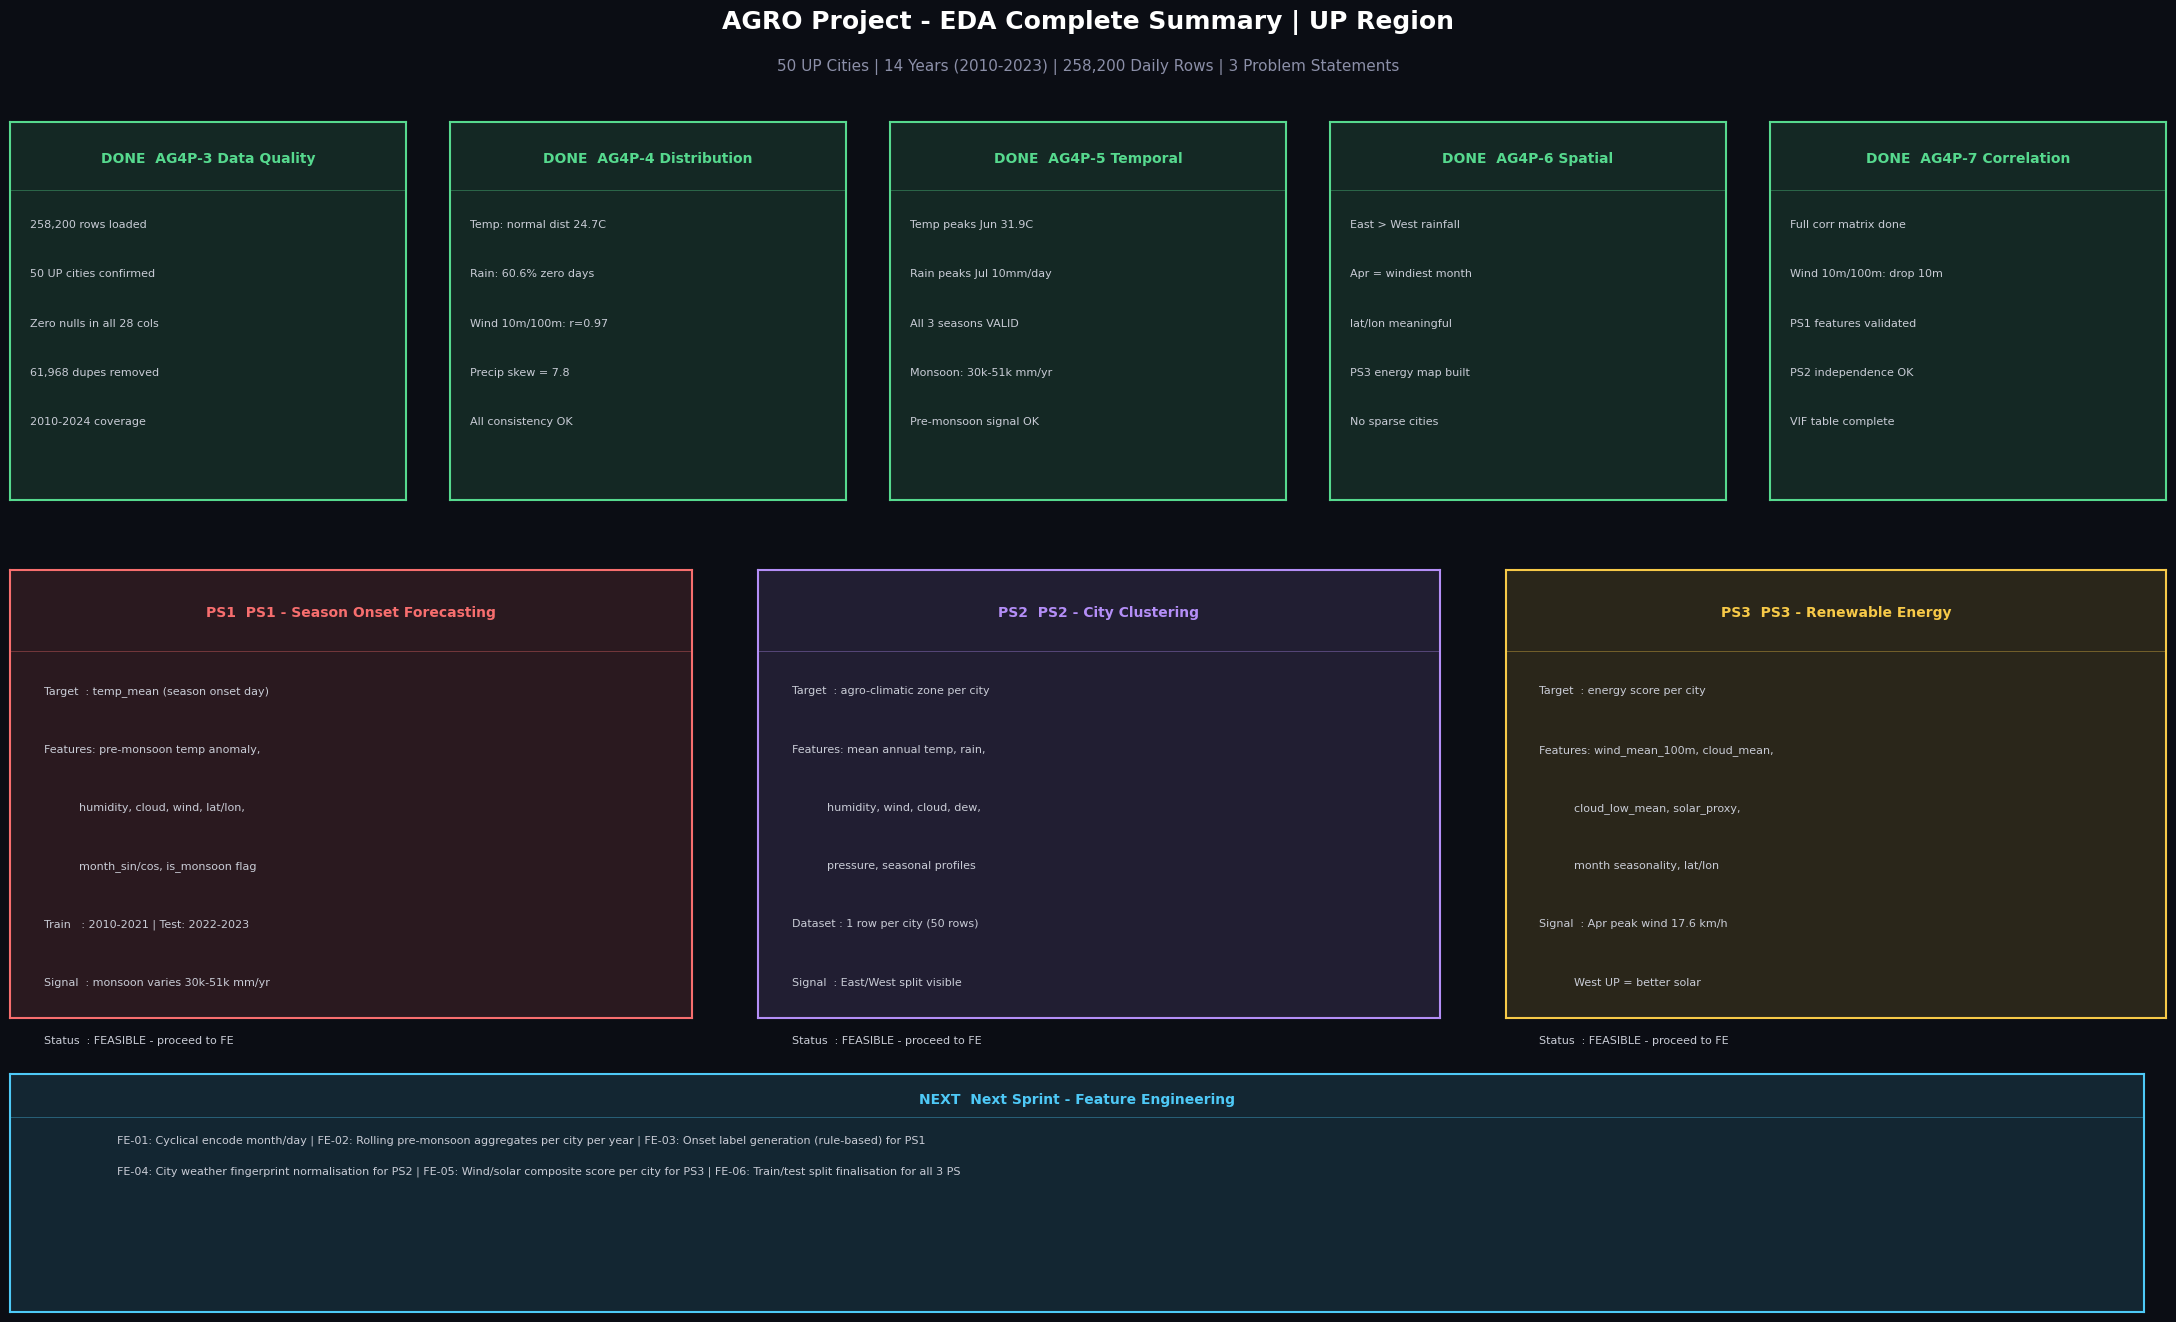

Saved: ag4p8_eda_summary.png


In [0]:
print("=" * 60)
print("AG4P-8 | STEP 7 - EDA Summary Visual")
print("=" * 60)

fig = plt.figure(figsize=(22, 14))
fig.patch.set_facecolor('#0b0d14')

# Title
fig.text(
    0.5, 0.97,
    'AGRO Project - EDA Complete Summary | UP Region',
    fontsize=18, fontweight='bold', color='white',
    ha='center', va='top'
)
fig.text(
    0.5, 0.935,
    '50 UP Cities | 14 Years (2010-2023) | 258,200 Daily Rows | 3 Problem Statements',
    fontsize=11, color='#8b8fa8', ha='center', va='top'
)

def draw_box(pos, title, lines, color, icon=''):
    ax = fig.add_axes(pos)
    ax.set_facecolor(color + '22')
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(1.5)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(
        0.5, 0.92, icon + '  ' + title,
        transform=ax.transAxes,
        fontsize=10, fontweight='bold',
        color=color, ha='center', va='top'
    )
    ax.axhline(0.82, color=color, lw=0.5, alpha=0.5)
    for i, line in enumerate(lines):
        ax.text(
            0.05, 0.74 - i * 0.13, line,
            transform=ax.transAxes,
            fontsize=8, color='#c9ccd6', va='top'
        )

# Row 1 — EDA Subtasks
draw_box([0.01, 0.62, 0.18, 0.27], 'AG4P-3 Data Quality',
         ['258,200 rows loaded',
          '50 UP cities confirmed',
          'Zero nulls in all 28 cols',
          '61,968 dupes removed',
          '2010-2024 coverage'],
         '#56d98e', 'DONE')

draw_box([0.21, 0.62, 0.18, 0.27], 'AG4P-4 Distribution',
         ['Temp: normal dist 24.7C',
          'Rain: 60.6% zero days',
          'Wind 10m/100m: r=0.97',
          'Precip skew = 7.8',
          'All consistency OK'],
         '#56d98e', 'DONE')

draw_box([0.41, 0.62, 0.18, 0.27], 'AG4P-5 Temporal',
         ['Temp peaks Jun 31.9C',
          'Rain peaks Jul 10mm/day',
          'All 3 seasons VALID',
          'Monsoon: 30k-51k mm/yr',
          'Pre-monsoon signal OK'],
         '#56d98e', 'DONE')

draw_box([0.61, 0.62, 0.18, 0.27], 'AG4P-6 Spatial',
         ['East > West rainfall',
          'Apr = windiest month',
          'lat/lon meaningful',
          'PS3 energy map built',
          'No sparse cities'],
         '#56d98e', 'DONE')

draw_box([0.81, 0.62, 0.18, 0.27], 'AG4P-7 Correlation',
         ['Full corr matrix done',
          'Wind 10m/100m: drop 10m',
          'PS1 features validated',
          'PS2 independence OK',
          'VIF table complete'],
         '#56d98e', 'DONE')

# Row 2 — Problem Statements
draw_box([0.01, 0.25, 0.31, 0.32],
         'PS1 - Season Onset Forecasting',
         ['Target  : temp_mean (season onset day)',
          'Features: pre-monsoon temp anomaly,',
          '          humidity, cloud, wind, lat/lon,',
          '          month_sin/cos, is_monsoon flag',
          'Train   : 2010-2021 | Test: 2022-2023',
          'Signal  : monsoon varies 30k-51k mm/yr',
          'Status  : FEASIBLE - proceed to FE'],
         '#f76e6e', 'PS1')

draw_box([0.35, 0.25, 0.31, 0.32],
         'PS2 - City Clustering',
         ['Target  : agro-climatic zone per city',
          'Features: mean annual temp, rain,',
          '          humidity, wind, cloud, dew,',
          '          pressure, seasonal profiles',
          'Dataset : 1 row per city (50 rows)',
          'Signal  : East/West split visible',
          'Status  : FEASIBLE - proceed to FE'],
         '#b48ef7', 'PS2')

draw_box([0.69, 0.25, 0.30, 0.32],
         'PS3 - Renewable Energy',
         ['Target  : energy score per city',
          'Features: wind_mean_100m, cloud_mean,',
          '          cloud_low_mean, solar_proxy,',
          '          month seasonality, lat/lon',
          'Signal  : Apr peak wind 17.6 km/h',
          '          West UP = better solar',
          'Status  : FEASIBLE - proceed to FE'],
         '#f7c948', 'PS3')

# Row 3 — Next Steps
draw_box([0.01, 0.04, 0.97, 0.17],
         'Next Sprint - Feature Engineering',
         ['FE-01: Cyclical encode month/day | '
          'FE-02: Rolling pre-monsoon aggregates per city per year | '
          'FE-03: Onset label generation (rule-based) for PS1',
          'FE-04: City weather fingerprint normalisation for PS2 | '
          'FE-05: Wind/solar composite score per city for PS3 | '
          'FE-06: Train/test split finalisation for all 3 PS'],
         '#4ec9f7', 'NEXT')

plt.savefig(
    SAVE + 'ag4p8_eda_summary.png',
    dpi=150, bbox_inches='tight',
    facecolor='#0b0d14'
)
plt.show()
print("Saved: ag4p8_eda_summary.png")